In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Set plot style
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('Libraries imported successfully!')

Libraries imported successfully!


In [5]:
# Load the Dataset
df = pd.read_csv(r'C:\Users\HP\Downloads\Global Superstore (1).csv', encoding='latin1')

print(f'Shape: {df.shape}')  # rows x columns
df.head()

Shape: (51290, 27)


,Category,City,Country,Customer ID,Customer Name,Discount,Market,ji_lu-shu,Order Date,Order ID,...,Sales,Segment,Ship Date,Ship Mode,Shipping Cost,State,Sub-Category,Year,Market2,weeknum
0,Office Supplies,Los Angeles,United States,LS-172304,Lycoris Saunders,0.0,US,1,00:00.0,CA-2011-130813,...,19,Consumer,00:00.0,Second Class,4.37,California,Paper,2011,North America,2
1,Office Supplies,Los Angeles,United States,MV-174854,Mark Van Huff,0.0,US,1,00:00.0,CA-2011-148614,...,19,Consumer,00:00.0,Standard Class,0.94,California,Paper,2011,North America,4
2,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,21,Consumer,00:00.0,Standard Class,1.81,California,Paper,2011,North America,32
3,Office Supplies,Los Angeles,United States,CS-121304,Chad Sievert,0.0,US,1,00:00.0,CA-2011-118962,...,111,Consumer,00:00.0,Standard Class,4.59,California,Paper,2011,North America,32
4,Office Supplies,Los Angeles,United States,AP-109154,Arthur Prichep,0.0,US,1,00:00.0,CA-2011-146969,...,6,Consumer,00:00.0,Standard Class,1.32,California,Paper,2011,North America,40


In [6]:
#exploratory data analysis (EDA)
# Basic info
print('--- Data Types ---')
print(df.dtypes)
print('\n--- Missing Values ---')
print(df.isnull().sum())

--- Data Types ---
Category           object
City               object
Country            object
Customer ID        object
Customer Name      object
Discount          float64
Market             object
ji_lu-shu           int64
Order Date         object
Order ID           object
Order Priority     object
Product ID         object
Product Name       object
Profit            float64
Quantity            int64
Region             object
Row ID              int64
Sales               int64
Segment            object
Ship Date          object
Ship Mode          object
Shipping Cost     float64
State              object
Sub-Category       object
Year                int64
Market2            object
weeknum             int64
dtype: object

--- Missing Values ---
Category          0
City              0
Country           0
Customer ID       0
Customer Name     0
Discount          0
Market            0
ji_lu-shu         0
Order Date        0
Order ID          0
Order Priority    0
Product ID        0
P

In [7]:
# Profit Distribution 
#Lets see how profit is spread across all orde
# Statistical summary of numeric columns
df[['Sales', 'Profit', 'Discount', 'Quantity', 'Shipping Cost']].describe().round(2)

,Sales,Profit,Discount,Quantity,Shipping Cost
count,51290.00,51290.00,51290.00,51290.00,51290.00
mean,246.50,28.61,0.14,3.48,26.38
std,487.57,174.34,0.21,2.28,57.30
min,0.00,-6599.98,0.00,1.00,0.00
25%,31.00,0.00,0.00,2.00,2.61
50%,85.00,9.24,0.00,3.00,7.79
75%,251.00,36.81,0.20,5.00,24.45
max,22638.00,8399.98,0.85,14.00,933.57


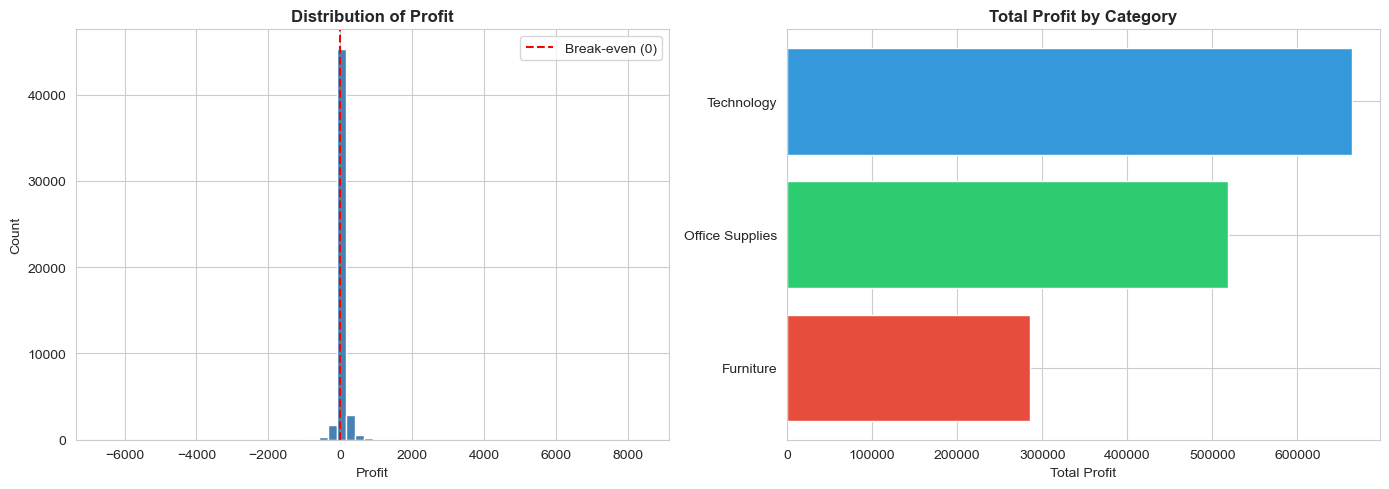

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of Profit
axes[0].hist(df['Profit'], bins=60, color='steelblue', edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', label='Break-even (0)')
axes[0].set_title('Distribution of Profit',fontweight='bold')
axes[0].set_xlabel('Profit')
axes[0].set_ylabel('Count')
axes[0].legend()

# Profit by Category
category_profit = df.groupby('Category')['Profit'].sum().sort_values()
axes[1].barh(category_profit.index, category_profit.values, color=['#e74c3c','#2ecc71','#3498db'])
axes[1].set_title('Total Profit by Category',fontweight='bold')
axes[1].set_xlabel('Total Profit')

plt.tight_layout()
plt.show()


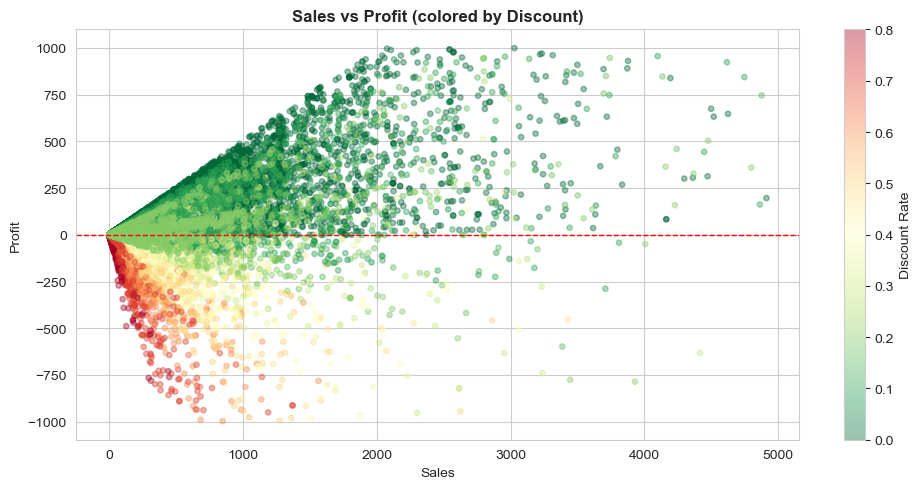

Insight: High discount (red dots) often leads to negative profit!


In [9]:
#Sales VS Profit (scatter plot)
plt.figure(figsize=(10, 5))
# Cap extreme values for better visibility
sample = df[(df['Sales'] < 5000) & (df['Profit'].between(-1000, 1000))]

plt.scatter(sample['Sales'], sample['Profit'],
            c=sample['Discount'], cmap='RdYlGn_r', alpha=0.4, s=15)
plt.colorbar(label='Discount Rate')
plt.axhline(0, color='red', linestyle='--', linewidth=1)
plt.title('Sales vs Profit (colored by Discount)',fontweight='bold')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.tight_layout()
plt.show()

print('Insight: High discount (red dots) often leads to negative profit!')


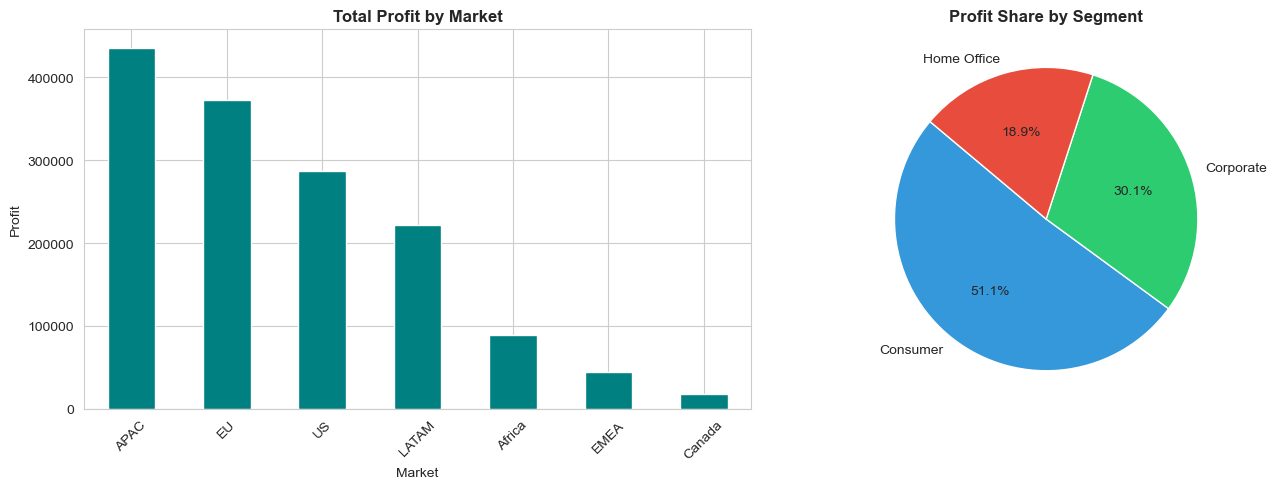

In [10]:
# Profit by market and segment
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Profit by Market
market_profit = df.groupby('Market')['Profit'].sum().sort_values(ascending=False)
market_profit.plot(kind='bar', ax=axes[0], color='teal', edgecolor='white')
axes[0].set_title('Total Profit by Market',fontweight='bold')
axes[0].set_xlabel('Market')
axes[0].set_ylabel('Profit')
axes[0].tick_params(axis='x', rotation=45)

# Profit by Segment
segment_profit = df.groupby('Segment')['Profit'].sum()
axes[1].pie(segment_profit, labels=segment_profit.index,
            autopct='%1.1f%%', colors=['#3498db','#2ecc71','#e74c3c'],
            startangle=140)
axes[1].set_title('Profit Share by Segment',fontweight='bold')

plt.tight_layout()
plt.show()

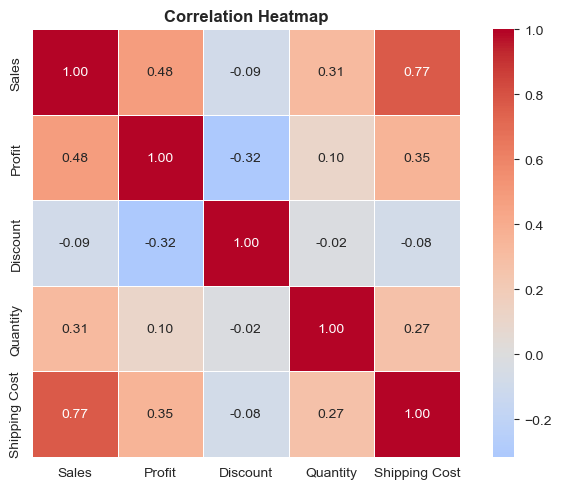

Discount has a negative correlation with Profit — more discount = less profit!


In [12]:
#Correlation heatmap
numeric_cols = ['Sales', 'Profit', 'Discount', 'Quantity', 'Shipping Cost']
corr = df[numeric_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, square=True)
plt.title('Correlation Heatmap',fontweight='bold')
plt.tight_layout()
plt.show()

print('Discount has a negative correlation with Profit — more discount = less profit!')